## Part B: Dataset Understanding & Preparation

* Identify independent and dependent variables.

#### Independent Variables-
 house_id, area_sqft, bedrooms, bathrooms, location_score, age_years, distance_city_km, lot_size_sqft, has_garage, has_pool, renovation_years_ago

#### Dependent Variable-
 house_price_inr

* Load dataset

In [19]:
import pandas as pd
df=pd.read_csv('real_estate_preprocessed.csv')
df.head()

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,100001,0.690424,5.0,4.0,7.600000,1.0,0.381197,0.700302,1.0,0.0,1.000000,1.327625
1,100002,0.101317,3.0,3.0,6.300000,1.0,0.526719,0.268813,1.0,0.0,0.071429,0.566003
2,100003,0.810017,4.0,3.0,5.800000,1.0,0.698079,0.060065,0.0,0.0,0.100000,0.734562
3,100004,1.357822,5.0,3.0,5.610638,1.0,0.204188,0.060065,1.0,1.0,0.200000,1.453055
4,100005,-0.002070,3.0,3.0,3.800000,1.0,0.782714,-0.300670,0.0,0.0,0.062500,-0.226520


* Visualize relationships between features and target variable.

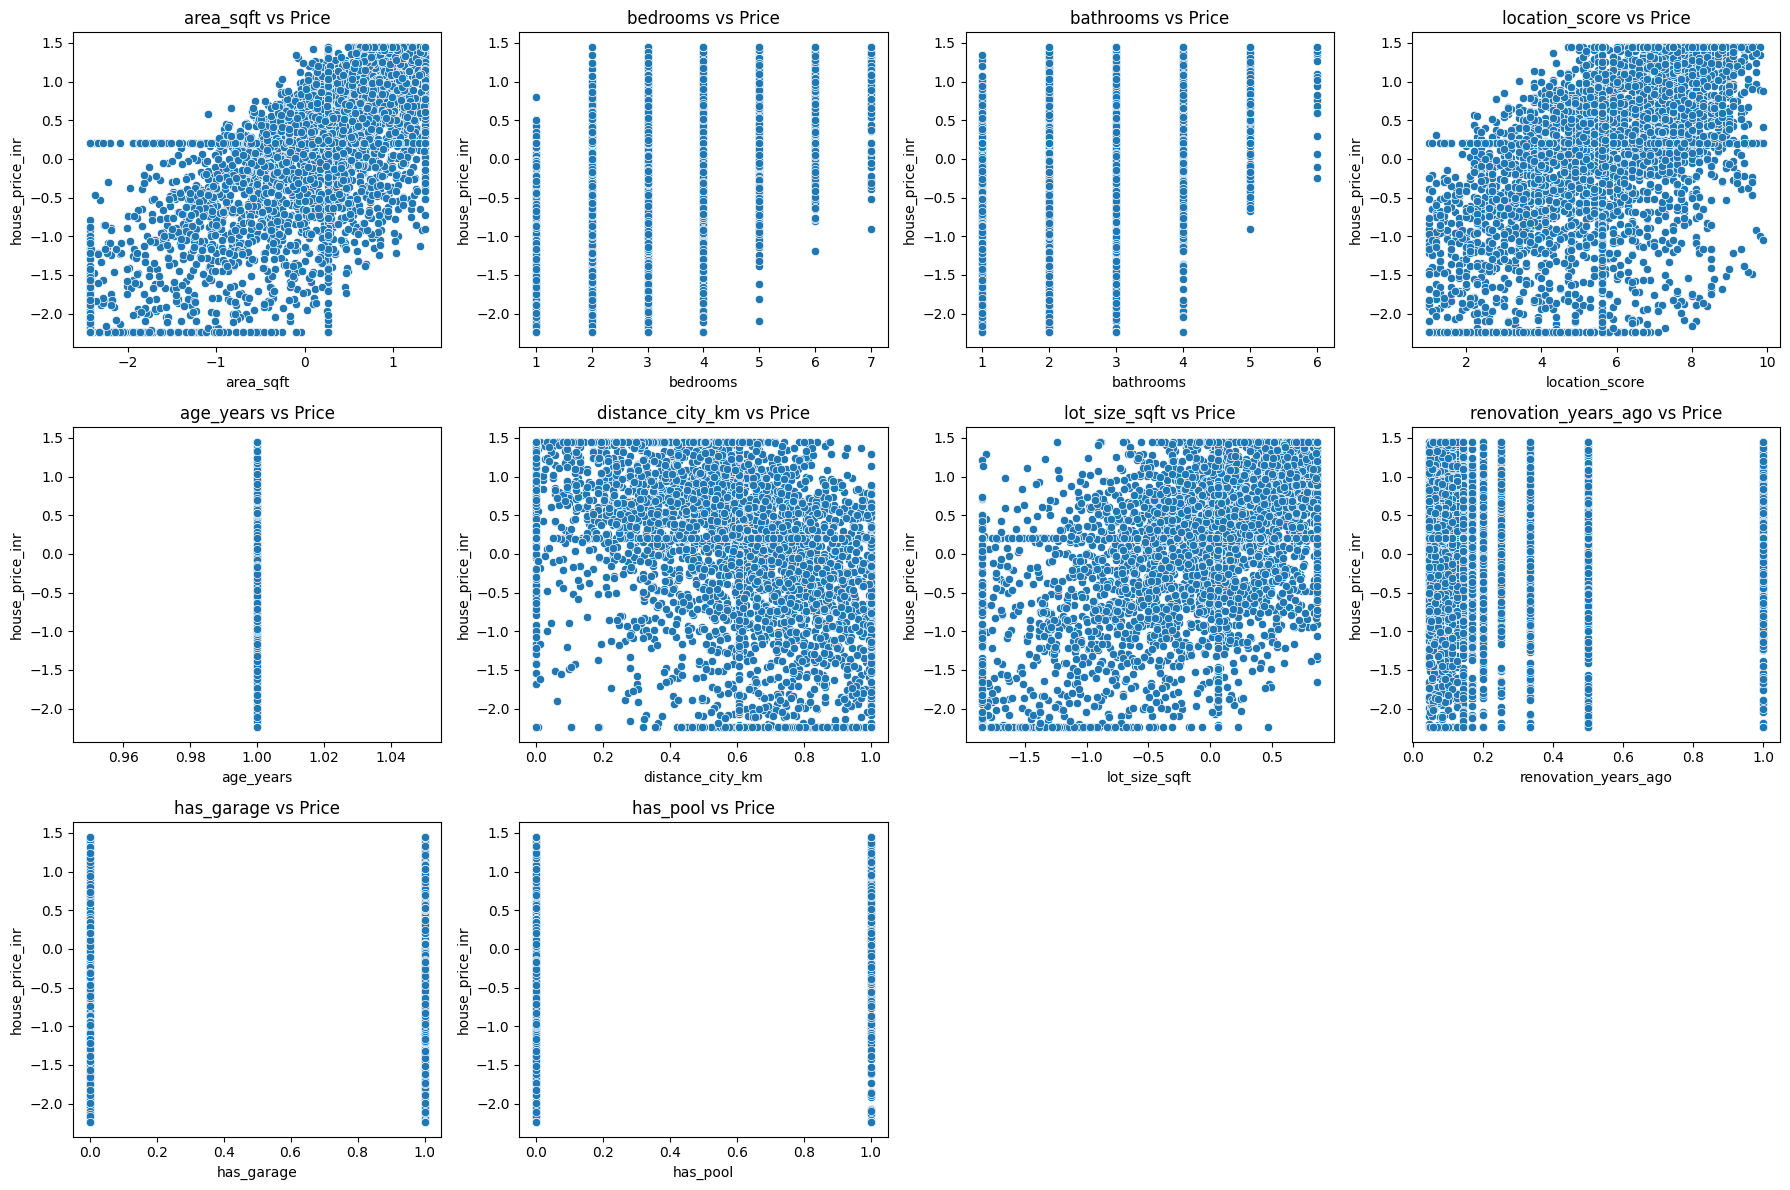

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['area_sqft','bedrooms','bathrooms','location_score','age_years','distance_city_km','lot_size_sqft','renovation_years_ago','has_garage','has_pool']
plt.figure(figsize=(18,12))

for i, col in enumerate(cols, 1):
    plt.subplot(3, 4, i)
    sns.scatterplot(x=df[col], y=df['house_price_inr'])
    plt.title(f"{col} vs Price")

plt.tight_layout()
plt.show()

* Split the dataset into training and testing sets.

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
X=df.iloc[:,0:11]
X.head()

y=df.iloc[:,11]
print(X,y)

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

      house_id  area_sqft  bedrooms  bathrooms  location_score  age_years  \
0       100001   0.690424       5.0        4.0        7.600000        1.0   
1       100002   0.101317       3.0        3.0        6.300000        1.0   
2       100003   0.810017       4.0        3.0        5.800000        1.0   
3       100004   1.357822       5.0        3.0        5.610638        1.0   
4       100005  -0.002070       3.0        3.0        3.800000        1.0   
...        ...        ...       ...        ...             ...        ...   
4016    104196  -0.312131       4.0        2.0        4.900000        1.0   
4017    104197   1.132068       6.0        4.0        6.900000        1.0   
4018    104198  -2.329455       2.0        2.0        4.500000        1.0   
4019    104199  -2.430618       2.0        2.0        7.500000        1.0   
4020    104200   0.267590       4.0        3.0        6.800000        1.0   

      distance_city_km  lot_size_sqft  has_garage  has_pool  \
0           

## Part C: Simple Linear Regression
* Plot before linear regression

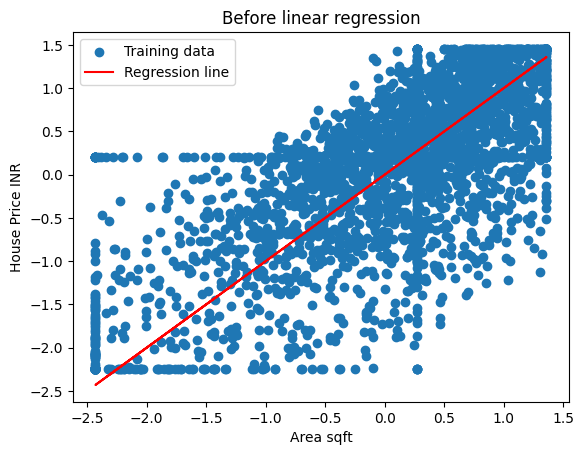

In [22]:
plt.scatter(X_train['area_sqft'], y_train, label='Training data')
plt.plot(X_train['area_sqft'], X_train['area_sqft'], color='red', label='Regression line')
plt.xlabel('Area sqft')
plt.ylabel('House Price INR')
plt.title('Before linear regression')
plt.legend()
plt.show()

* Implement Simple Linear Regression using one feature (e.g., House Area).

In [23]:
x_simp = X_train['area_sqft'].values.reshape(-1, 1)
x_simp2 = X_test['area_sqft'].values.reshape(-1, 1)

lr1 = LinearRegression()
lr1.fit(x_simp, y_train)

predictions = lr1.predict(X_test['area_sqft'].values.reshape(-1, 1))
print(predictions)

[-1.17813832e+00  2.03787899e-01  3.62790176e-04 ...  9.94749898e-01
  1.51410704e-01  2.03787899e-01]


* Plot the regression line and interpret the slope and intercept.

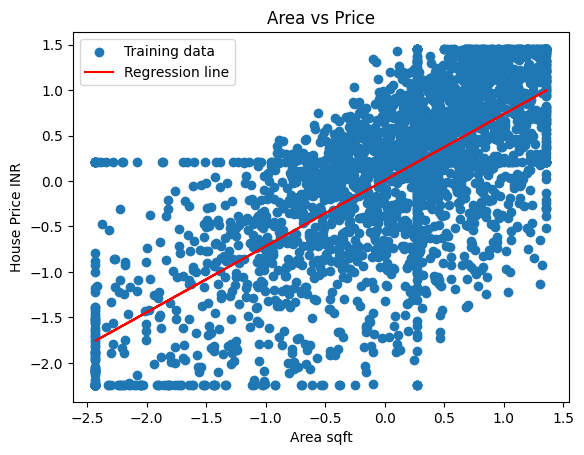

In [24]:
plt.scatter(X_train['area_sqft'], y_train, label='Training data')
plt.plot(X_train['area_sqft'], lr1.predict(x_simp), color='red', label='Regression line')

plt.xlabel('Area sqft')
plt.ylabel('House Price INR')
plt.title('Area vs Price')
plt.legend()
plt.show()

* Interpretation of Slope and Intercept

In [ ]:
print(f'Intercept: {lr1.intercept_}, \ncoefficient: {lr1.coef_}')

Intercept: 0.009322271882242612, 
coefficient: [0.72673109]


* Residual and homoscedasticity

3273   -0.746045
1204   -1.010731
2720    0.418671
1954    0.641143
1226    0.120680
Name: house_price_inr, dtype: float64

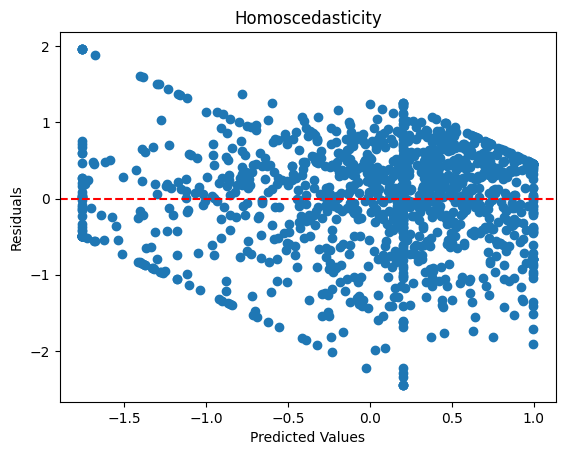

In [ ]:
residuals = y_test - predictions
plt.scatter(predictions, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Homoscedasticity')

residuals.head()

* Validate linear regression assumptions using plots and observations.

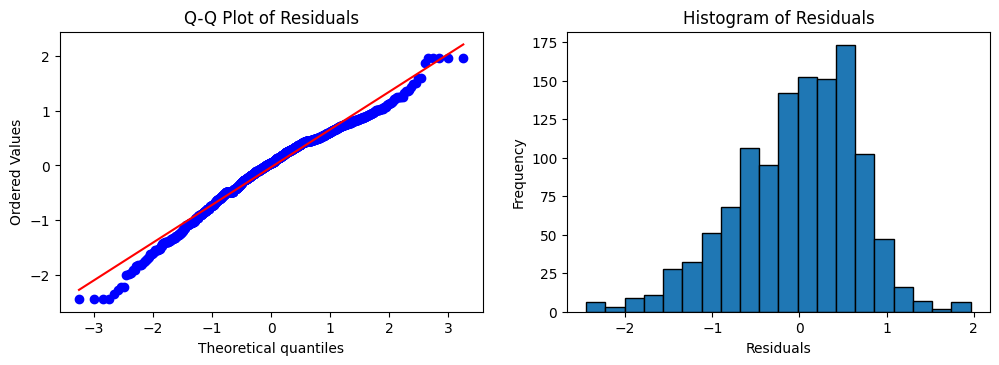

In [ ]:
import scipy.stats as stats

plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals')

plt.subplot(2, 2, 2)
plt.hist(residuals, bins=20, edgecolor='black')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals')

plt.show()

## Part D: Model Evaluation Metrics

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
mse = mean_squared_error(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
rmse = mse ** 0.5
r2 = r2_score(y_test, predictions)
n = len(y_test)
ar2 = 1 - ((1 - r2) * (n - 1)) / (n - 1 - 1)
print(f'mse: {mse}')
print(f'mae: {mae}')
print(f'rmse: {rmse}')
print(f'r2: {r2}')
print(f'adjusted r2: {ar2}')

mse: 0.4867562255583512
mae: 0.5490733906604484
rmse: 0.6976791709362916
r2: 0.545982926715421
adjusted r2: 0.5456061490612429


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = X_train.copy()
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns

vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(len(X_vif.columns))
]

print(vif_data)

                 Feature          VIF
0               house_id     1.005213
1              area_sqft     3.379929
2               bedrooms     3.325490
3              bathrooms     2.160707
4         location_score     1.915326
5              age_years  7289.346483
6       distance_city_km     1.888197
7          lot_size_sqft     2.145378
8             has_garage     1.073370
9               has_pool     1.029596
10  renovation_years_ago     1.001640
